In [5]:
import pandas as pd
import numpy as mp
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('etrain_delays.csv')
df.head()

,train_number,train_name,station_code,station_name,average_delay_minutes,pct_right_time,pct_slight_delay,pct_significant_delay,pct_cancelled_unknown,scraped_at,source_url
0,12673,Cheran Express,MAS,CHENNAI CENTRAL,2.0,98.90,0.27,0.00,0.83,2025-09-27T12:25:37.767628+00:00,https://etrain.info/train/Cheran-Express-12673...
1,12673,Cheran Express,AVD,AVADI,0.0,0.27,0.00,0.00,99.73,2025-09-27T12:25:39.293769+00:00,https://etrain.info/train/Cheran-Express-12673...
2,12673,Cheran Express,AJJ,ARAKKONAM,16.0,55.34,44.38,0.27,0.01,2025-09-27T12:25:40.672610+00:00,https://etrain.info/train/Cheran-Express-12673...
3,12673,Cheran Express,KPD,KATPADI JN,17.0,48.49,49.86,1.64,0.01,2025-09-27T12:25:42.125216+00:00,https://etrain.info/train/Cheran-Express-12673...
4,12673,Cheran Express,JTJ,JOLARPETTAI,NaN,70.96,27.67,1.37,0.00,2025-09-27T12:25:44.585700+00:00,https://etrain.info/train/Cheran-Express-12673...


In [6]:
print(df.columns.tolist())
print(df.isnull().sum())
print(df.dtypes)

['train_number', 'train_name', 'station_code', 'station_name', 'average_delay_minutes', 'pct_right_time', 'pct_slight_delay', 'pct_significant_delay', 'pct_cancelled_unknown', 'scraped_at', 'source_url']
train_number               0
train_name                 0
station_code               0
station_name               0
average_delay_minutes    236
pct_right_time             0
pct_slight_delay           0
pct_significant_delay      0
pct_cancelled_unknown      0
scraped_at                 0
source_url                 0
dtype: int64
train_number               int64
train_name                   str
station_code                 str
station_name                 str
average_delay_minutes    float64
pct_right_time           float64
pct_slight_delay         float64
pct_significant_delay    float64
pct_cancelled_unknown    float64
scraped_at                   str
source_url                   str
dtype: object


In [7]:
# Drop rows where average_delay_minutes is missing
df_clean = df.dropna(subset=['average_delay_minutes'])

# Drop columns we don't need for analysis
df_clean = df_clean.drop(columns=['scraped_at', 'source_url'])

# Reset index
df_clean = df_clean.reset_index(drop=True)

print(f"Original rows: {len(df)}")
print(f"Clean rows: {len(df_clean)}")
df_clean.head()

Original rows: 1900
Clean rows: 1664


,train_number,train_name,station_code,station_name,average_delay_minutes,pct_right_time,pct_slight_delay,pct_significant_delay,pct_cancelled_unknown
0,12673,Cheran Express,MAS,CHENNAI CENTRAL,2.0,98.90,0.27,0.00,0.83
1,12673,Cheran Express,AVD,AVADI,0.0,0.27,0.00,0.00,99.73
2,12673,Cheran Express,AJJ,ARAKKONAM,16.0,55.34,44.38,0.27,0.01
3,12673,Cheran Express,KPD,KATPADI JN,17.0,48.49,49.86,1.64,0.01
4,12673,Cheran Express,SA,SALEM JN,25.0,23.01,74.79,2.19,0.01


In [8]:
# Basic statistics of delay
print("=== Delay Statistics ===")
print(f"Average delay across all stations: {df_clean['average_delay_minutes'].mean():.2f} minutes")
print(f"Maximum delay recorded: {df_clean['average_delay_minutes'].max():.2f} minutes")
print(f"Minimum delay recorded: {df_clean['average_delay_minutes'].min():.2f} minutes")
print(f"Median delay: {df_clean['average_delay_minutes'].median():.2f} minutes")

# On time performance overview
print("\n=== On Time Performance ===")
print(f"Average % right time: {df_clean['pct_right_time'].mean():.2f}%")
print(f"Average % slight delay: {df_clean['pct_slight_delay'].mean():.2f}%")
print(f"Average % significant delay: {df_clean['pct_significant_delay'].mean():.2f}%")
print(f"Average % cancelled/unknown: {df_clean['pct_cancelled_unknown'].mean():.2f}%")

=== Delay Statistics ===
Average delay across all stations: 40.70 minutes
Maximum delay recorded: 586.00 minutes
Minimum delay recorded: 0.00 minutes
Median delay: 24.00 minutes

=== On Time Performance ===
Average % right time: 49.78%
Average % slight delay: 33.32%
Average % significant delay: 15.73%
Average % cancelled/unknown: 1.17%


In [9]:
# Top 10 worst trains by average delay
worst_trains = df_clean.groupby(['train_number', 'train_name'])['average_delay_minutes'].mean().reset_index()
worst_trains = worst_trains.sort_values('average_delay_minutes', ascending=False).head(10)

print("=== Top 10 Most Delayed Trains ===")
print(worst_trains.to_string(index=False))

# Top 10 worst stations by average delay
worst_stations = df_clean.groupby('station_name')['average_delay_minutes'].mean().reset_index()
worst_stations = worst_stations.sort_values('average_delay_minutes', ascending=False).head(10)

print("\n=== Top 10 Most Delayed Stations ===")
print(worst_stations.to_string(index=False))

=== Top 10 Most Delayed Trains ===
 train_number           train_name  average_delay_minutes
        12261       Howrah Duronto             370.500000
        12262       Howrah Duronto             316.833333
        12236      Duronto Express             148.000000
        12509 Guwahati Sbc Express             143.189189
        12839          Howrah Mail             109.365079
        12626       Kerala Express             101.051282
        12840          Howrah Mail             100.814286
        12510 Sbc Guwahati Express              87.973684
        12245      Duronto Express              78.200000
        12842   Coromandel Express              65.529412

=== Top 10 Most Delayed Stations ===
 station_name  average_delay_minutes
     AKOLA JN             429.500000
 TATANAGAR JN             338.500000
  BILASPUR JN             299.500000
      DANKUNI             149.000000
   RAMPUR HAT             132.000000
  SAMALKOT JN             126.500000
NIDADAVOLU JN             124.

In [10]:
# Top 10 most reliable trains
best_trains = df_clean.groupby(['train_number', 'train_name'])['pct_right_time'].mean().reset_index()
best_trains = best_trains.sort_values('pct_right_time', ascending=False).head(10)

print("=== Top 10 Most Reliable Trains ===")
print(best_trains.to_string(index=False))

=== Top 10 Most Reliable Trains ===
 train_number              train_name  pct_right_time
        12306        Kolkata Rajdhani      100.000000
        12049        Gatimaan Express       98.075000
        12957 Swarna Jayanti Rajdhani       96.252500
        12680    Coimbatore Intercity       93.333077
        12313        Sealdah Rajdhani       89.583750
        12434                Rajdhani       88.890000
        12019                Shatabdi       88.000000
        20665            Vande Bharat       87.912857
        22221     Mumbai Vande Bharat       87.778333
        12951         Mumbai Rajdhani       85.890000


In [11]:
# How many stations fall in each delay category
bins = [0, 15, 60, 200, 600]
labels = ['On Time (0-15 min)', 'Slight Delay (15-60 min)', 'Significant Delay (60-200 min)', 'Severe Delay (200+ min)']
df_clean['delay_category'] = pd.cut(df_clean['average_delay_minutes'], bins=bins, labels=labels)

print("=== Delay Category Distribution ===")
print(df_clean['delay_category'].value_counts())

=== Delay Category Distribution ===
delay_category
Slight Delay (15-60 min)          841
On Time (0-15 min)                491
Significant Delay (60-200 min)    282
Severe Delay (200+ min)            32
Name: count, dtype: int64


In [12]:
# Top 10 stations with highest cancellation rates
cancellation_hotspots = df_clean.groupby('station_name')['pct_cancelled_unknown'].mean().reset_index()
cancellation_hotspots = cancellation_hotspots.sort_values('pct_cancelled_unknown', ascending=False).head(10)

print("=== Top 10 Cancellation Hotspots ===")
print(cancellation_hotspots.to_string(index=False))

=== Top 10 Cancellation Hotspots ===
   station_name  pct_cancelled_unknown
          AVADI              99.730000
 GOSSAIGAON HAT              98.280000
  BHODWAL MAJRI              91.235000
       SHALIMAR              90.000000
BANDRA TERMINUS              77.530000
SIRPUR KAGAZNGR              63.340000
       AKOLA JN              59.385000
         KODURU              48.495000
      BARSOI JN              32.693333
SHRI MAHAVEERJI              32.603333


In [13]:
# Build a custom reliability score per train
# Formula: (pct_right_time * 0.5) + ((100 - pct_significant_delay) * 0.3) + ((100 - pct_cancelled_unknown) * 0.2)
df_clean['reliability_score'] = (
    (df_clean['pct_right_time'] * 0.5) +
    ((100 - df_clean['pct_significant_delay']) * 0.3) +
    ((100 - df_clean['pct_cancelled_unknown']) * 0.2)
)

reliability = df_clean.groupby(['train_number', 'train_name'])['reliability_score'].mean().reset_index()
reliability = reliability.sort_values('reliability_score', ascending=False)

print("=== Top 10 Most Reliable Trains (Custom Score) ===")
print(reliability.head(10).to_string(index=False))

print("\n=== Bottom 10 Least Reliable Trains (Custom Score) ===")
print(reliability.tail(10).to_string(index=False))

=== Top 10 Most Reliable Trains (Custom Score) ===
 train_number              train_name  reliability_score
        12306        Kolkata Rajdhani         100.000000
        12049        Gatimaan Express          99.037500
        12957 Swarna Jayanti Rajdhani          97.127000
        12680    Coimbatore Intercity          96.666538
        12434                Rajdhani          94.445000
        12313        Sealdah Rajdhani          94.291875
        12019                Shatabdi          94.000000
        20665            Vande Bharat          93.461429
        22221     Mumbai Vande Bharat          93.389000
        20666            Vande Bharat          92.857143

=== Bottom 10 Least Reliable Trains (Custom Score) ===
 train_number           train_name  reliability_score
        12841   Coromandel Express          56.737571
        12236      Duronto Express          52.857143
        12245      Duronto Express          52.271600
        12510 Sbc Guwahati Express          48.946

In [14]:
# Cost of delay calculation
# Assumptions:
# - Average Indian Railways passenger values time at Rs 50/hour (conservative estimate)
# - Average train carries 500 passengers
# - We have data on X unique trains

unique_trains = df_clean['train_number'].nunique()
avg_delay_hours = df_clean['average_delay_minutes'].mean() / 60
cost_per_train_per_trip = avg_delay_hours * 500 * 50  # hours * passengers * Rs per hour
annual_trips_per_train = 365
total_annual_cost = cost_per_train_per_trip * annual_trips_per_train * unique_trains

print(f"=== Cost of Delay Estimate ===")
print(f"Unique trains analyzed: {unique_trains}")
print(f"Average delay per train: {avg_delay_hours:.2f} hours")
print(f"Estimated cost per train per trip: Rs {cost_per_train_per_trip:,.0f}")
print(f"Estimated total annual passenger time cost: Rs {total_annual_cost:,.0f}")
print(f"That is approximately Rs {total_annual_cost/10000000:.1f} Crore annually")

=== Cost of Delay Estimate ===
Unique trains analyzed: 90
Average delay per train: 0.68 hours
Estimated cost per train per trip: Rs 16,958
Estimated total annual passenger time cost: Rs 557,074,669
That is approximately Rs 55.7 Crore annually


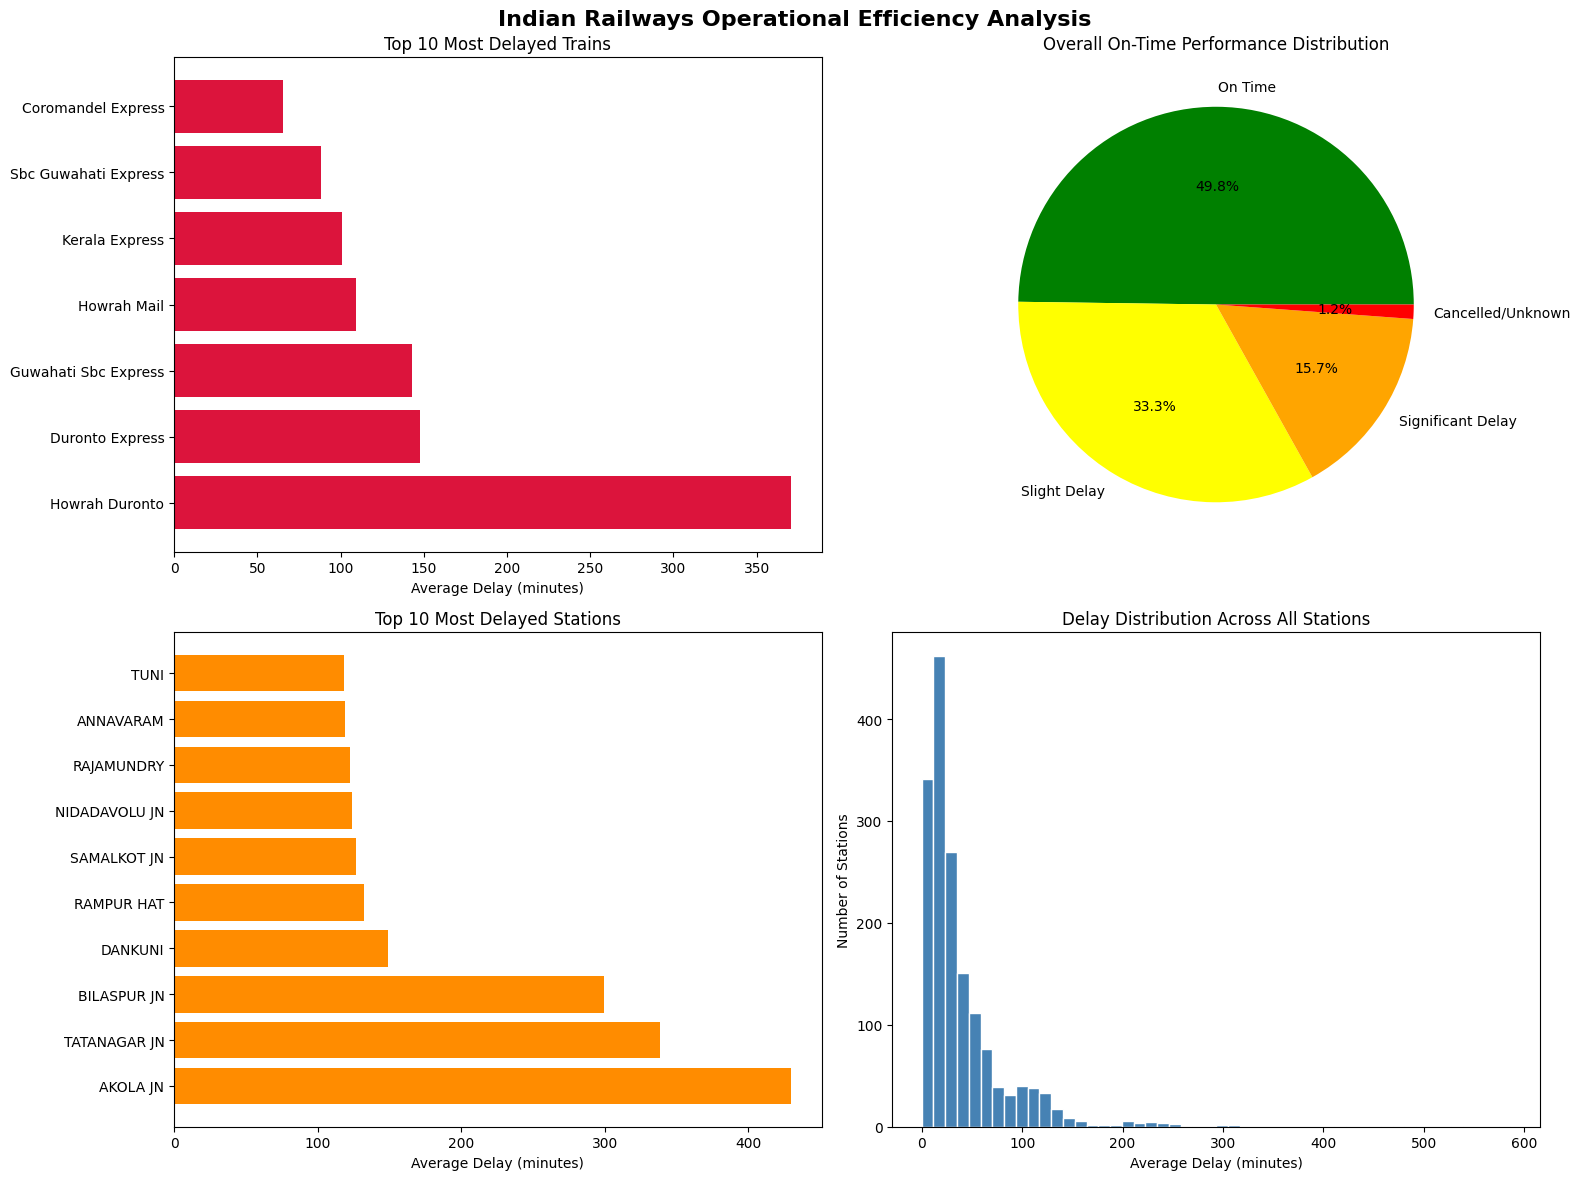

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Indian Railways Operational Efficiency Analysis', fontsize=16, fontweight='bold')

# Plot 1 — Top 10 most delayed trains
axes[0,0].barh(worst_trains['train_name'], worst_trains['average_delay_minutes'], color='crimson')
axes[0,0].set_title('Top 10 Most Delayed Trains')
axes[0,0].set_xlabel('Average Delay (minutes)')

# Plot 2 — On time performance overview
labels_pie = ['On Time', 'Slight Delay', 'Significant Delay', 'Cancelled/Unknown']
sizes = [
    df_clean['pct_right_time'].mean(),
    df_clean['pct_slight_delay'].mean(),
    df_clean['pct_significant_delay'].mean(),
    df_clean['pct_cancelled_unknown'].mean()
]
colors = ['green', 'yellow', 'orange', 'red']
axes[0,1].pie(sizes, labels=labels_pie, colors=colors, autopct='%1.1f%%')
axes[0,1].set_title('Overall On-Time Performance Distribution')

# Plot 3 — Top 10 most delayed stations
axes[1,0].barh(worst_stations['station_name'], worst_stations['average_delay_minutes'], color='darkorange')
axes[1,0].set_title('Top 10 Most Delayed Stations')
axes[1,0].set_xlabel('Average Delay (minutes)')

# Plot 4 — Delay distribution histogram
axes[1,1].hist(df_clean['average_delay_minutes'], bins=50, color='steelblue', edgecolor='white')
axes[1,1].set_title('Delay Distribution Across All Stations')
axes[1,1].set_xlabel('Average Delay (minutes)')
axes[1,1].set_ylabel('Number of Stations')

plt.tight_layout()
plt.savefig('railways_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Export clean data for Tableau
df_clean.to_csv('railways_clean.csv', index=False)

# Export worst trains for Tableau
worst_trains.to_csv('worst_trains.csv', index=False)

# Export worst stations for Tableau 

print("All files exported successfully")

All files exported successfully


In [17]:
top10_delayed = df_clean.groupby('train_name')['average_delay_minutes'].mean().reset_index()
top10_delayed = top10_delayed.sort_values('average_delay_minutes', ascending=False).head(10)
print(top10_delayed.to_string(index=False))

          train_name  average_delay_minutes
      Howrah Duronto             347.500000
Guwahati Sbc Express             143.189189
         Howrah Mail             104.864662
Sbc Guwahati Express              87.973684
     Duronto Express              65.423077
      Kerala Express              63.712500
  Coromandel Express              56.838710
      Tamil Nadu Exp              40.260870
 Vikramshila Express              39.289474
    Devagiri Express              37.117647


In [18]:
import sqlite3

# Load clean data into SQLite database
conn = sqlite3.connect('railways.db')
df_clean.to_sql('delays', conn, if_exists='replace', index=False)

# Query 1 — Top 10 most delayed trains using SQL
query1 = """
SELECT train_name, ROUND(AVG(average_delay_minutes), 2) as avg_delay
FROM delays
GROUP BY train_name
ORDER BY avg_delay DESC
LIMIT 10
"""
print("=== Top 10 Most Delayed Trains (SQL) ===")
print(pd.read_sql_query(query1, conn))

# Query 2 — On time performance by train
query2 = """
SELECT train_name, ROUND(AVG(pct_right_time), 2) as avg_on_time
FROM delays
GROUP BY train_name
ORDER BY avg_on_time DESC
LIMIT 10
"""
print("\n=== Top 10 Most Reliable Trains (SQL) ===")
print(pd.read_sql_query(query2, conn))

Task was destroyed but it is pending!
task: <Task pending name='Task-842' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/riyatuscano/Desktop/railways-analysis/venv/lib/python3.13/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-843' coro=<Kernel.shell_main() running at /Users/riyatuscano/Desktop/railways-analysis/venv/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/riyatuscano/Desktop/railways-analysis/venv/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py:563]>
/Users/riyatuscano/Desktop/railways-analysis/venv/lib/python3.13/site-packages/pandas/io/sql.py:2569: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  data_list = list(data_iter)
Task was destroyed but it is pending!
task: <Task pending name='Task-843' coro=<Kernel.shell_main() running at /Users/riyatuscano/Desktop/railways-analysis/venv/lib/python3.13/site-packag

=== Top 10 Most Delayed Trains (SQL) ===
             train_name  avg_delay
0        Howrah Duronto     347.50
1  Guwahati Sbc Express     143.19
2           Howrah Mail     104.86
3  Sbc Guwahati Express      87.97
4       Duronto Express      65.42
5        Kerala Express      63.71
6    Coromandel Express      56.84
7        Tamil Nadu Exp      40.26
8   Vikramshila Express      39.29
9      Devagiri Express      37.12

=== Top 10 Most Reliable Trains (SQL) ===
                train_name  avg_on_time
0  Swarna Jayanti Rajdhani        88.67
1         Sealdah Rajdhani        82.82
2     Chennai Vande Bharat        82.25
3         Gatimaan Express        81.54
4                 Rajdhani        80.86
5   August Kranti Rajdhani        79.57
6          Mumbai Rajdhani        79.31
7          Howrah Rajdhani        78.70
8             Vande Bharat        78.31
9                 Shatabdi        77.60
